# ASL Dataset - Exploratory Data Analysis

This notebook covers:
1. Class distribution per dataset and combined
2. Image statistics (dimensions, aspect ratio, brightness, channel means)
3. Per-class sample grids
4. pHash duplicate analysis with threshold sweep
5. Post-dedup class distribution
6. Imbalance analysis and class-weight derivation
7. Augmentation justification (why horizontal/vertical flips are excluded)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve().parent / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import imagehash

from config import load_config

cfg = load_config('../configs/config.yaml')
print(f'Environment: {cfg.env}')
print(f'Data root: {cfg.data_root}')
print(f'Classes: {len(cfg.classes)} - {cfg.classes}')

[config] environment: local
Environment: local
Data root: data
Classes: 37 - ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing']


## 1. Raw manifest - class distribution per dataset

Total images: 104,058
Sources: ['combine_asl' 'asl_hg_raw' 'asl_alphabet']
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing']


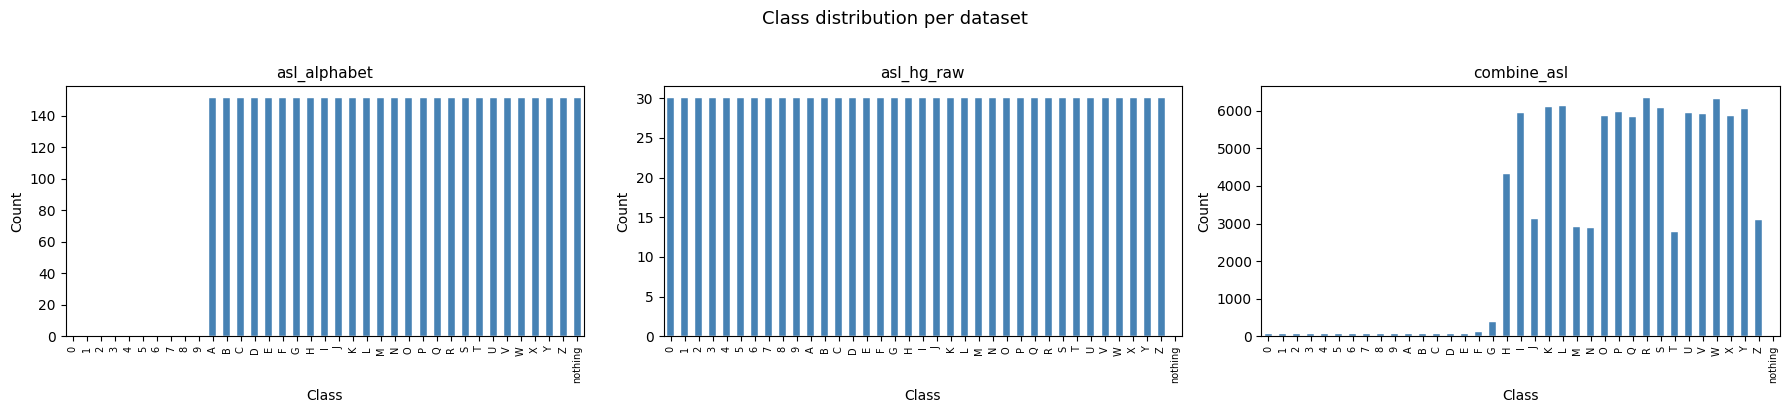

In [2]:
manifest_path = '..' / cfg.data_root / 'manifest_raw.csv'
if not manifest_path.exists():
    print('Manifest not found. Run data_unification.py first.')
else:
    df = pd.read_csv(manifest_path)
    print(f'Total images: {len(df):,}')
    print(f'Sources: {df["source_dataset"].unique()}')
    print(f'Classes: {sorted(df["class_name"].unique())}')

    # Per-source counts
    fig, axes = plt.subplots(1, len(df['source_dataset'].unique()), figsize=(18, 4), sharey=False)
    for ax, (src, sub) in zip(axes, df.groupby('source_dataset')):
        counts = sub.groupby('class_name').size().reindex(cfg.classes, fill_value=0)
        counts.plot.bar(ax=ax, color='steelblue', edgecolor='white', linewidth=0.3)
        ax.set_title(src, fontsize=11)
        ax.set_xlabel('Class')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', labelsize=7, rotation=90)
    plt.suptitle('Class distribution per dataset', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

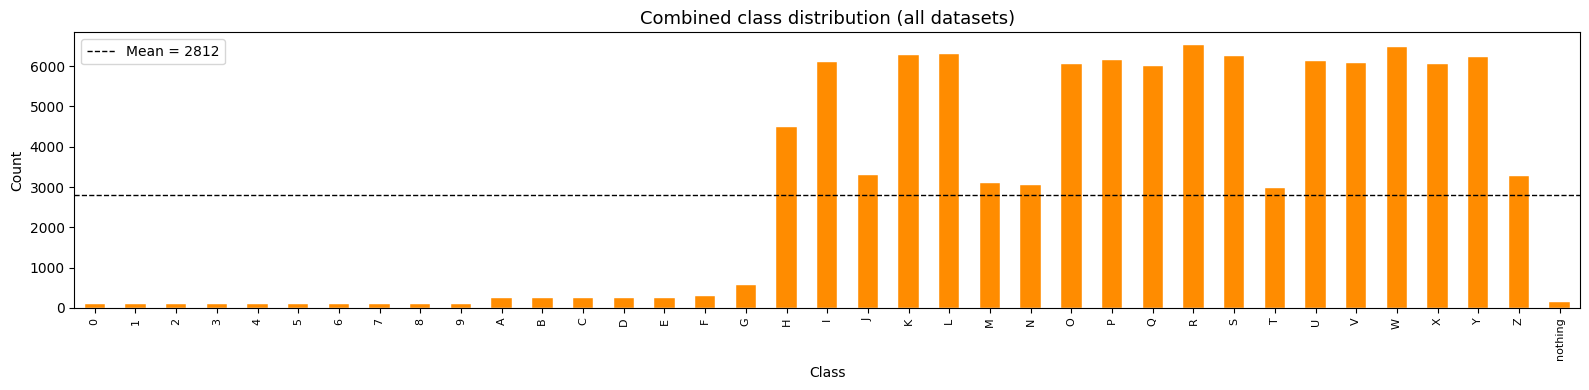

Imbalance ratio (max/min): 65.1x
Most common: R (6,512)
Least common: 0 (100)


In [3]:
# Combined distribution
df = pd.read_csv(manifest_path)  # reload to ensure all data is included
combined = df.groupby('class_name').size().reindex(cfg.classes, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 4))
combined.plot.bar(ax=ax, color='darkorange', edgecolor='white', linewidth=0.3)
ax.axhline(combined.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean = {combined.mean():.0f}')
ax.set_title('Combined class distribution (all datasets)', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', labelsize=8, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

imbalance_ratio = combined.max() / combined.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x')
print(f'Most common: {combined.idxmax()} ({combined.max():,})')
print(f'Least common: {combined.idxmin()} ({combined.min():,})')

## 2. Image statistics

Image stats:   0%|          | 0/2000 [00:00<?, ?it/s]

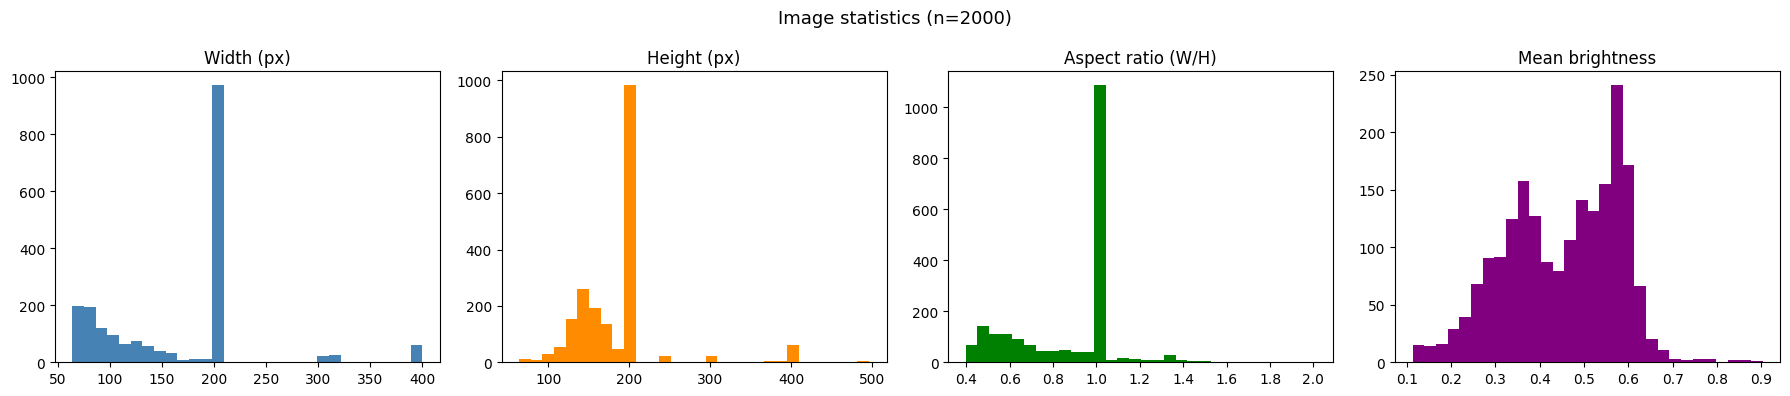

Width: 164 ± 72 px
Height: 185 ± 55 px
Channel means (R/G/B): 0.491 / 0.429 / 0.435


In [4]:
SAMPLE_N = 2000  # sample for speed
sample = df.sample(min(SAMPLE_N, len(df)), random_state=42)

widths, heights, aspects, brightnesses = [], [], [], []
ch_means = [[], [], []]

for path in tqdm(sample['filepath'], desc='Image stats'):
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspects.append(w / h)
            arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
            brightnesses.append(arr.mean())
            for c in range(3):
                ch_means[c].append(arr[:, :, c].mean())
    except Exception:
        pass

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].hist(widths, bins=30, color='steelblue'); axes[0].set_title('Width (px)')
axes[1].hist(heights, bins=30, color='darkorange'); axes[1].set_title('Height (px)')
axes[2].hist(aspects, bins=30, color='green'); axes[2].set_title('Aspect ratio (W/H)')
axes[3].hist(brightnesses, bins=30, color='purple'); axes[3].set_title('Mean brightness')
plt.suptitle(f'Image statistics (n={len(widths)})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Width: {np.mean(widths):.0f} ± {np.std(widths):.0f} px')
print(f'Height: {np.mean(heights):.0f} ± {np.std(heights):.0f} px')
print(f'Channel means (R/G/B): {np.mean(ch_means[0]):.3f} / {np.mean(ch_means[1]):.3f} / {np.mean(ch_means[2]):.3f}')

## 3. Per-class sample grids

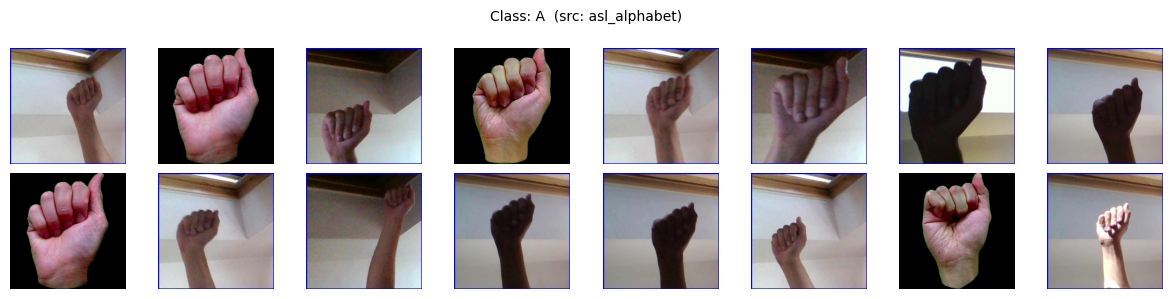

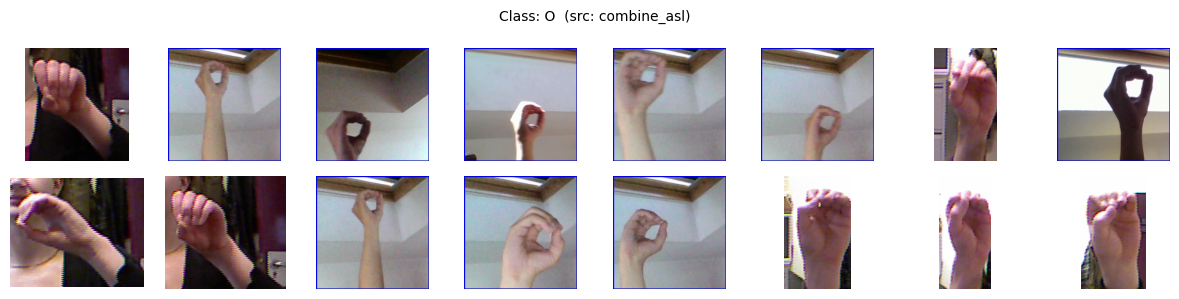

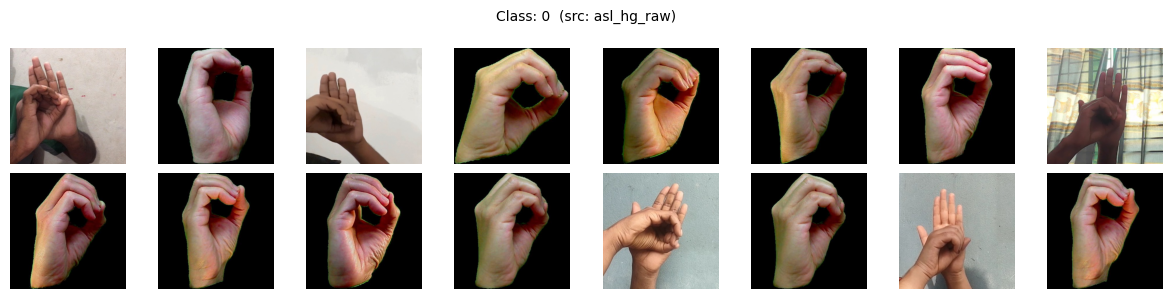

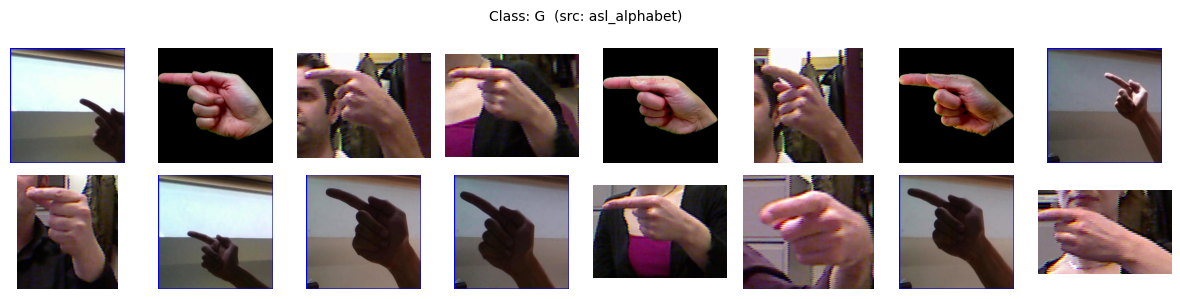

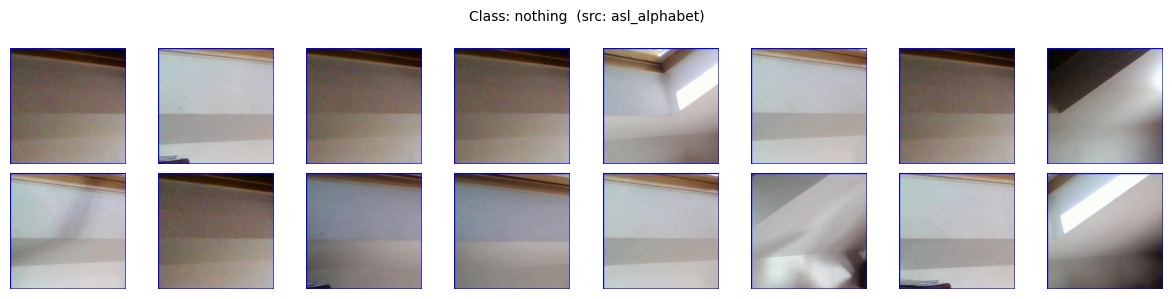

In [5]:
def show_class_grid(df, class_name, n_cols=8, n_rows=2):
    sub = df[df['class_name'] == class_name].sample(min(n_cols * n_rows, len(df[df['class_name'] == class_name])), random_state=42)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, sub.iterrows()):
        try:
            img = Image.open(row['filepath']).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'err', ha='center', va='center')
        ax.axis('off')
    for ax in axes[len(sub):]:
        ax.axis('off')
    fig.suptitle(f'Class: {class_name}  (src: {sub["source_dataset"].values[0]})', fontsize=10)
    plt.tight_layout()
    plt.show()

# Show a few interesting classes
for cls in ['A', 'O', '0', 'G', 'nothing']:
    if cls in df['class_name'].values:
        show_class_grid(df, cls)

## 4. Augmentation justification - horizontal flip danger

Horizontal flipping mirrors the hand, which:
- Converts a right-hand sign to a left-hand sign (different in ASL for letters like G, H, P, Q)
- Creates a visually near-identical sign to a *different* letter, artificially inflating performance

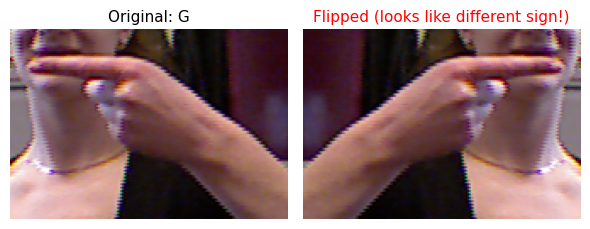

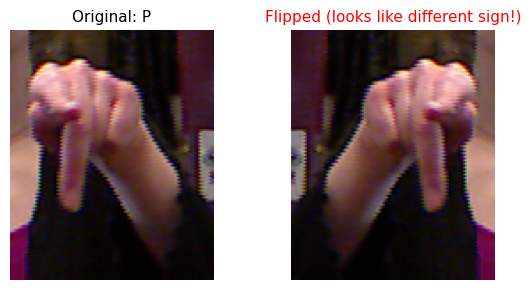

In [6]:
# Visual demonstration: show G and P original vs flipped
for cls in ['G', 'P']:
    sub = df[df['class_name'] == cls]
    if len(sub) == 0:
        continue
    path = sub.iloc[0]['filepath']
    img = Image.open(path).convert('RGB')
    flipped = img.transpose(Image.FLIP_LEFT_RIGHT)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(img); axes[0].set_title(f'Original: {cls}', fontsize=11); axes[0].axis('off')
    axes[1].imshow(flipped); axes[1].set_title(f'Flipped (looks like different sign!)', fontsize=11, color='red'); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## 5. pHash duplicate analysis

Sweeping class "I": 6111 images


pHash:   0%|          | 0/6111 [00:00<?, ?it/s]

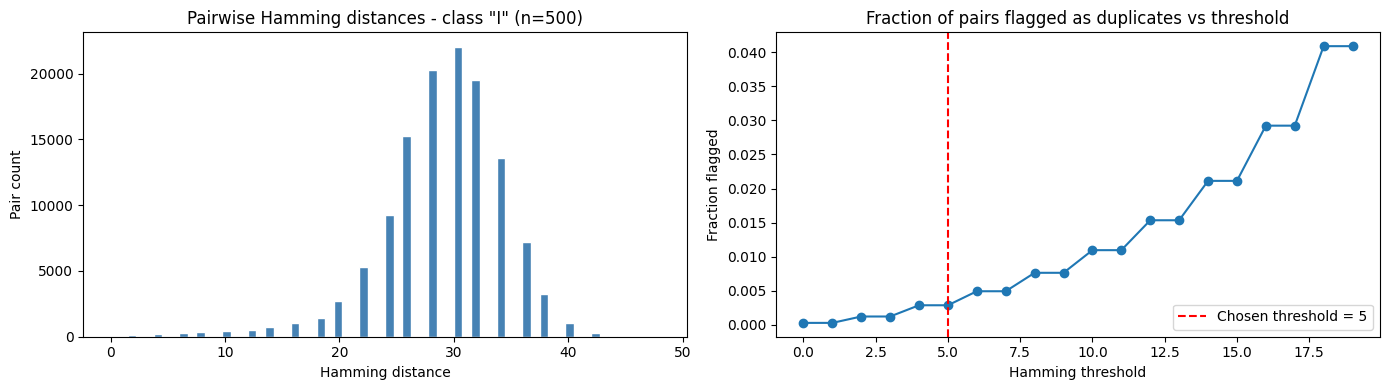

In [7]:
# Threshold sweep on a sample to pick the right Hamming distance cutoff.
# We sample one class to keep it fast.

SWEEP_CLASS = 'I'
sweep_df = df[df['class_name'] == SWEEP_CLASS].copy()
print(f'Sweeping class "{SWEEP_CLASS}": {len(sweep_df)} images')

hashes = []
for path in tqdm(sweep_df['filepath'], desc='pHash'):
    try:
        with Image.open(path) as img:
            hashes.append(imagehash.phash(img, hash_size=8))
    except Exception:
        hashes.append(imagehash.phash(Image.new('RGB', (8,8))))

# Compute all pairwise distances (sample up to 500 for speed)
n = min(500, len(hashes))
sub_hashes = hashes[:n]
distances = []
for i in range(n):
    for j in range(i+1, n):
        distances.append(sub_hashes[i] - sub_hashes[j])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(distances, bins=64, color='steelblue', edgecolor='white')
axes[0].set_title(f'Pairwise Hamming distances - class "{SWEEP_CLASS}" (n={n})')
axes[0].set_xlabel('Hamming distance'); axes[0].set_ylabel('Pair count')

thresholds = list(range(0, 20))
dup_fracs = [sum(1 for d in distances if d <= t) / len(distances) for t in thresholds]
axes[1].plot(thresholds, dup_fracs, marker='o')
axes[1].axvline(5, color='red', linestyle='--', label='Chosen threshold = 5')
axes[1].set_title('Fraction of pairs flagged as duplicates vs threshold')
axes[1].set_xlabel('Hamming threshold'); axes[1].set_ylabel('Fraction flagged')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Post-dedup distribution

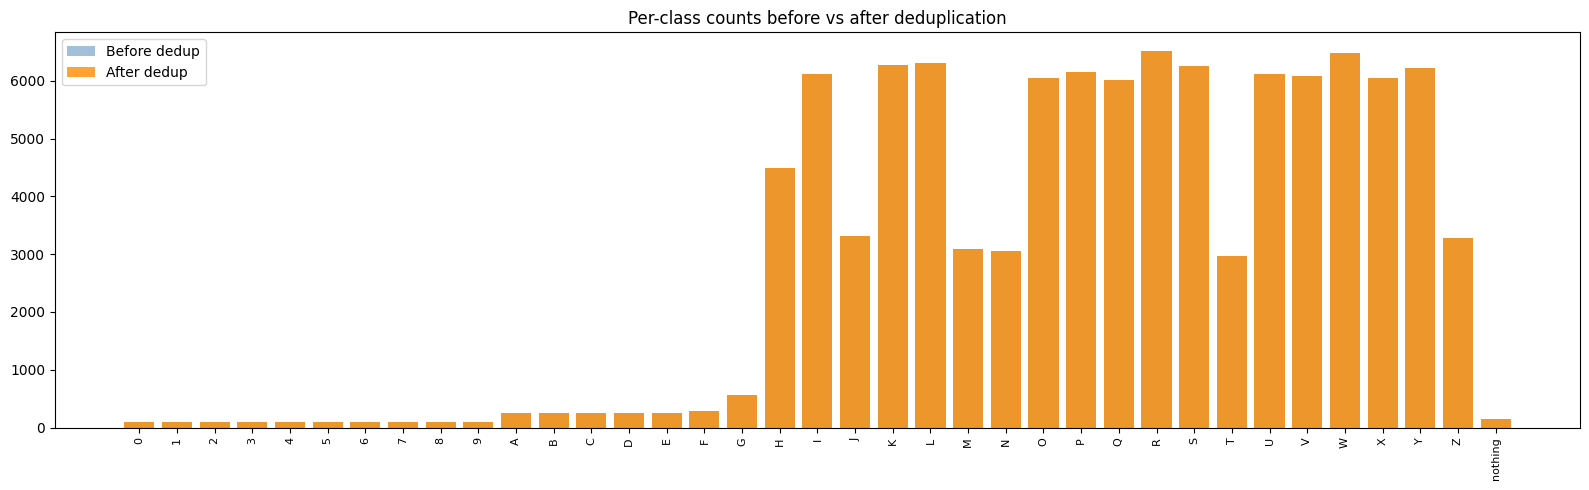

Raw images: 104,058
Dropped (invalid): 0
Duplicate groups: 34,720
After dedup: 104,058


In [8]:
import json

report_path = '..'/ cfg.data_root / 'dedup_report.json'
if report_path.exists():
    with open(report_path) as f:
        report = json.load(f)

    before = pd.Series(report['per_class_before']).reindex(cfg.classes, fill_value=0)
    after = pd.Series(report['per_class_after']).reindex(cfg.classes, fill_value=0)

    fig, ax = plt.subplots(figsize=(16, 5))
    x = range(len(cfg.classes))
    ax.bar(x, before, alpha=0.5, label='Before dedup', color='steelblue')
    ax.bar(x, after, alpha=0.8, label='After dedup', color='darkorange')
    ax.set_xticks(list(x))
    ax.set_xticklabels(cfg.classes, fontsize=8, rotation=90)
    ax.set_title('Per-class counts before vs after deduplication')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'Raw images: {report["total_raw"]:,}')
    print(f'Dropped (invalid): {report["dropped_invalid"]:,}')
    print(f'Duplicate groups: {report["n_groups"]:,}')
    print(f'After dedup: {report["after_validation"]:,}')
else:
    print('Run preprocessing.py first to generate dedup_report.json')

## 7. Class weights for imbalance-aware loss

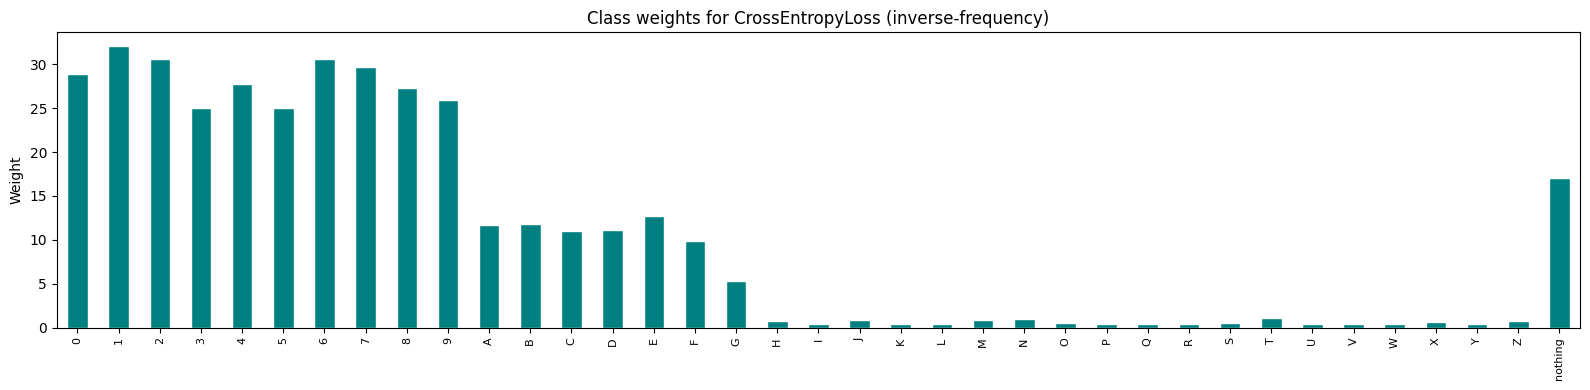

Weights (first 10 classes):
0    28.889608
1    32.049409
2    30.614361
3    25.014173
4    27.718408
5    25.014173
6    30.614361
7    29.726988
8    27.348829
9    25.964078
dtype: float64


In [9]:
train_csv = '..'/ cfg.data_root / 'splits' / 'train.csv'
if train_csv.exists():
    train_df = pd.read_csv(train_csv)
    counts = train_df.groupby('class_name').size().reindex(cfg.classes, fill_value=1).values.astype(float)
    weights = counts.sum() / (len(cfg.classes) * counts)
    weights_series = pd.Series(weights, index=cfg.classes)

    fig, ax = plt.subplots(figsize=(16, 4))
    weights_series.plot.bar(ax=ax, color='teal', edgecolor='white')
    ax.set_title('Class weights for CrossEntropyLoss (inverse-frequency)', fontsize=12)
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    plt.tight_layout()
    plt.show()

    print('Weights (first 10 classes):')
    print(weights_series.head(10))
else:
    print('Run preprocessing.py first to generate splits.')